<class 'pandas.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   timestamp  213 non-null    str  
 1   user       213 non-null    str  
 2   ip         213 non-null    str  
 3   country    213 non-null    str  
 4   success    213 non-null    bool 
 5   os         213 non-null    str  
dtypes: bool(1), str(5)
memory usage: 8.7 KB
success
True     140
False     73
Name: count, dtype: int64


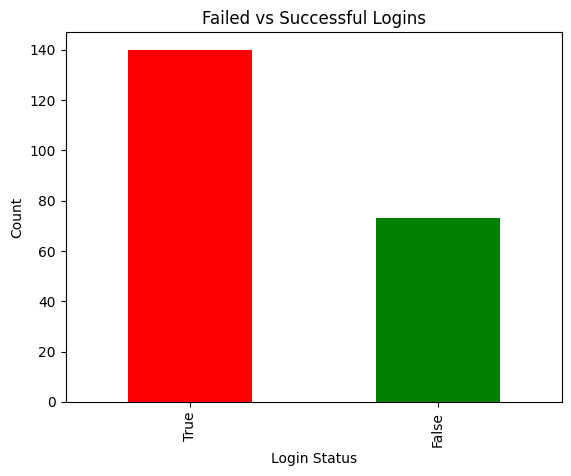

user
user_005    15
user_015     5
user_022     4
user_001     4
user_021     4
Name: count, dtype: int64
country
China           30
Kenya           26
Nigeria         23
Russia          20
South Africa    26
Uganda          23
Unknown         32
Name: ip, dtype: int64


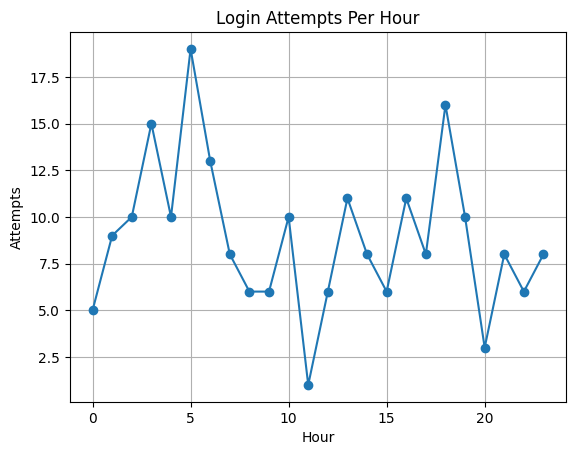

5
<StringArray>
['user_005']
Length: 1, dtype: str


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("system_logins.csv")
df.head()
df.info()

df.isnull().sum()
df = df.dropna()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

login_counts = df['success'].value_counts()

print(login_counts)

login_counts.plot(kind='bar', color=['red', 'green'])

plt.title("Failed vs Successful Logins")
plt.xlabel("Login Status")
plt.ylabel("Count")

plt.show()

failed = df[df['success'] == False]

top_users = failed['user'].value_counts().head(5)

print(top_users)

ip_counts = df.groupby('country')['ip'].nunique()

print(ip_counts)

hourly_logins = df.groupby('hour').size()

hourly_logins.plot(kind='line', marker='o')

plt.title("Login Attempts Per Hour")
plt.xlabel("Hour")
plt.ylabel("Attempts")

plt.grid(True)

plt.show()

failed_hour = failed.groupby('hour').size()

print(failed_hour.idxmax())

df = df.sort_values(['user', 'timestamp'])

df['prev_success'] = df['success'].shift()
df['prev_time'] = df['timestamp'].shift()
df['prev_user'] = df['user'].shift()

suspicious = df[
    (df['user'] == df['prev_user']) &
    (df['prev_success'] == False) &
    (df['success'] == True) &
    ((df['timestamp'] - df['prev_time']).dt.total_seconds() <= 300)
]

print(suspicious['user'].unique())

The hour with the highest failed logins may indicate suspicious login activity because many failed attempts happened during that time.

# Summary Report

1. The dataset was analyzed for suspicious login activity.
2. Failed logins were compared with successful logins.
3. Some users showed repeated failed login attempts.
4. Certain hours had unusually high login activity.
5. Suspicious login behavior may indicate brute-force attacks.

## Recommendations

- Enable multi-factor authentication (MFA).
- Lock accounts after multiple failed login attempts.
